In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\data-science-using-python\dirty_cafe_sales_cleaned.csv") 

print("Shape:", df.shape)
print(df.head())

Shape: (10000, 8)
  Transaction ID    Item  Quantity  Price Per Unit  Total Spent  \
0    TXN_1961373  Coffee       2.0             2.0          4.0   
1    TXN_4977031    Cake       4.0             3.0         12.0   
2    TXN_4271903  Cookie       4.0             1.0          NaN   
3    TXN_7034554   Salad       2.0             5.0         10.0   
4    TXN_3160411  Coffee       2.0             2.0          4.0   

   Payment Method  Location Transaction Date  
0             1.0  Takeaway       2023-09-08  
1             0.0  In-store       2023-05-16  
2             1.0  In-store       2023-07-19  
3             2.0  Takeaway       2023-04-27  
4             2.0  In-store       2023-06-11  


In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load dataset
df = pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\data-science-using-python\dirty_cafe_sales.csv")

print("Original Shape:", df.shape)

Original Shape: (10000, 8)


In [3]:
# Converting  numeric columns properly
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')


In [4]:
# Filling missing values with mean
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mean())
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].mean())
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].mean())

In [5]:
# Select numeric columns
numerical_data = df[['Quantity', 'Price Per Unit', 'Total Spent']]

print("Numerical Data Shape:", numerical_data.shape)

Numerical Data Shape: (10000, 3)


In [6]:
# Min-Max Normalization
minmax_scaler = MinMaxScaler()
normalized_data = minmax_scaler.fit_transform(numerical_data)

normalized_df = pd.DataFrame(normalized_data, columns=numerical_data.columns)

print("\nMin-Max Normalized Data:")
print(normalized_df.head())



Min-Max Normalized Data:
   Quantity  Price Per Unit  Total Spent
0      0.25            0.25     0.125000
1      0.75            0.50     0.458333
2      0.75            0.00     0.330181
3      0.25            1.00     0.375000
4      0.25            0.25     0.125000


In [7]:
# Standardization
standard_scaler = StandardScaler()
standardized_data = standard_scaler.fit_transform(numerical_data)

standardized_df = pd.DataFrame(standardized_data, columns=numerical_data.columns)

print("\nStandardized Data:")
print(standardized_df.head())

print("\nMean after Standardization:")
print(standardized_df.mean())

print("\nStandard Deviation after Standardization:")
print(standardized_df.std())


Standardized Data:
   Quantity  Price Per Unit   Total Spent
0 -0.742824       -0.763746 -8.407895e-01
1  0.701708        0.040211  5.251395e-01
2  0.701708       -1.567703  3.032972e-16
3 -0.742824        1.648125  1.836573e-01
4 -0.742824       -0.763746 -8.407895e-01

Mean after Standardization:
Quantity         -3.126388e-17
Price Per Unit   -1.669775e-16
Total Spent       2.394529e-16
dtype: float64

Standard Deviation after Standardization:
Quantity          1.00005
Price Per Unit    1.00005
Total Spent       1.00005
dtype: float64


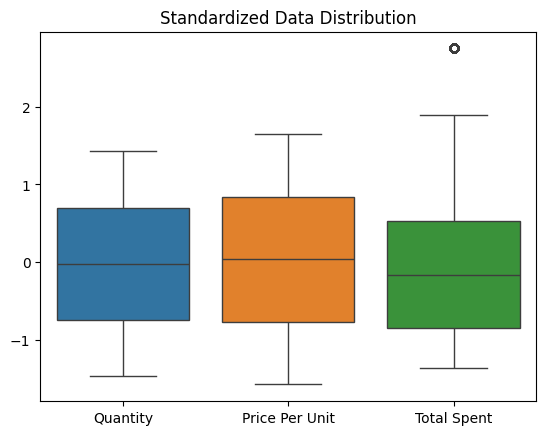

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=standardized_df)
plt.title("Standardized Data Distribution")
plt.show()
